# Extended Analysis Results

Inspection notebook for the extended-analysis pipeline output.  
Read top-to-bottom; no interactivity. All plots are reproducible matplotlib cells.

**Multi-run data** (`ext_*.csv`) = all 15 runs (`thesis_results/ext/final_lr{005,010,020}_seed{0,1,2,3,42}`).  
Every plot and table uses **seed-averaged statistics** (mean ± 1 SD across 5 seeds per LR).

In [1]:
# ── configuration ───────────────────────────────────────────────────────────
LOCK_K    = 52    # edit as needed
N_CLASSES = 10    # edit as needed

import os, glob, re, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from IPython.display import display, Image

warnings.filterwarnings('ignore')
matplotlib.rcParams.update({'figure.dpi': 110, 'font.size': 9})

# Consistent color per LR — blue=0.05, red=0.10, green=0.20
LR_COLORS = {0.05: '#4878CF', 0.10: '#D65F5F', 0.20: '#6ACC65'}

# ── root path (safe for both notebooks/ and project root) ────────────────
_cwd = os.getcwd().replace('\\', '/')
if _cwd.endswith('/notebooks') or '/notebooks/' in _cwd:
    ROOT = os.path.dirname(os.getcwd())
else:
    ROOT = os.getcwd()

# Final sanity-check: no double-thesis in the path
assert 'thesis/thesis' not in ROOT.replace('\\', '/'), \
    f'Double-thesis detected in ROOT: {ROOT}'

AGG     = os.path.join(ROOT, 'thesis_results', '_aggregate')
FIGS    = os.path.join(ROOT, 'thesis_results', '_figs')
EXT_DIR = os.path.join(ROOT, 'thesis_results', 'ext')

CSV_TYPES = ['similarity', 'probe_functional', 'subspace', 'fisher', 'rank_accuracy']

# ── multi-run loader ─────────────────────────────────────────────────────
def load_ext(name):
    """Glob all 15 run dirs, parse lr+seed from folder name, return concatenated DF."""
    pattern = os.path.join(EXT_DIR, '*', f'ext_{name}.csv')
    files = sorted(glob.glob(pattern))
    if not files:
        print(f'[SKIP] No files matching ext_{name}.csv at: {pattern}')
        return None
    parts = []
    for f in files:
        folder = os.path.basename(os.path.dirname(f))
        m = re.match(r'final_lr(\d{3})_seed(\w+)', folder)
        try:
            df = pd.read_csv(f)
            if m:
                df['lr']   = int(m.group(1)) / 100   # 005->0.05, 010->0.10, 020->0.20
                df['seed'] = int(m.group(2))
            parts.append(df)
        except Exception as e:
            print(f'[WARN] {f}: {e}')
    return pd.concat(parts, ignore_index=True) if parts else None

def load_agg(name):
    p = os.path.join(AGG, name)
    if not os.path.exists(p):
        print(f'[SKIP] not found: {p}')
        return None
    return pd.read_csv(p)

def show_png(name):
    p = os.path.join(FIGS, name)
    if os.path.exists(p):
        display(Image(p, width=800))
    else:
        print(f'[SKIP] PNG not found: {p}')

def safe_cols(df, wanted, context=''):
    """Return only columns that actually exist; print note for missing ones."""
    missing = [c for c in wanted if c not in df.columns]
    if missing:
        print(f'[NOTE{" " + context if context else ""}] columns not found (skipped): {missing}')
    return [c for c in wanted if c in df.columns]

print('ROOT    :', ROOT)
print('EXT_DIR :', EXT_DIR)
print('LOCK_K  :', LOCK_K, '  N_CLASSES:', N_CLASSES)
print('LR_COLORS:', LR_COLORS)

ROOT    : C:\Users\gabri\thesis
EXT_DIR : C:\Users\gabri\thesis\thesis_results\ext
LOCK_K  : 52   N_CLASSES: 10
LR_COLORS: {0.05: '#4878CF', 0.1: '#D65F5F', 0.2: '#6ACC65'}


---
## Chapter 0 — Data Overview

File listing, schema dump (one example per CSV type), and 75-file manifest confirming all runs loaded.

In [2]:
# ── list all 15 run directories ─────────────────────────────────────────────
runs = sorted(glob.glob(os.path.join(EXT_DIR, 'final_*')))
print(f'Found {len(runs)} run directories in ext/')
for r in runs:
    n_csv = len(glob.glob(os.path.join(r, '*.csv')))
    print(f'  {os.path.basename(r)}: {n_csv} CSVs')

Found 15 run directories in ext/
  final_lr005_seed0: 5 CSVs
  final_lr005_seed1: 5 CSVs
  final_lr005_seed2: 5 CSVs
  final_lr005_seed3: 5 CSVs
  final_lr005_seed42: 5 CSVs
  final_lr010_seed0: 5 CSVs
  final_lr010_seed1: 5 CSVs
  final_lr010_seed2: 5 CSVs
  final_lr010_seed3: 5 CSVs
  final_lr010_seed42: 5 CSVs
  final_lr020_seed0: 5 CSVs
  final_lr020_seed1: 5 CSVs
  final_lr020_seed2: 5 CSVs
  final_lr020_seed3: 5 CSVs
  final_lr020_seed42: 5 CSVs


In [3]:
# ── schema dump: one example per CSV type ───────────────────────────────────
print('Schema of each CSV type (example: final_lr010_seed0):\n')
for name in CSV_TYPES:
    example = os.path.join(EXT_DIR, 'final_lr010_seed0', f'ext_{name}.csv')
    if not os.path.exists(example):
        print(f'[SKIP] ext_{name}.csv: example file not found')
        continue
    df = pd.read_csv(example)
    print(f'=== ext_{name}.csv ===')
    print(f'  shape : {df.shape}')
    print(f'  cols  : {df.columns.tolist()}')
    display(df.head(3).round(4))
    print()

Schema of each CSV type (example: final_lr010_seed0):

=== ext_similarity.csv ===
  shape : (45, 11)
  cols  : ['run', 'lr', 'seed', 'epoch', 'cka_biased_tofinal', 'cka_debiased_tofinal', 'svcca_tofinal', 'cka_biased_tofinal_heldout', 'svcca_tofinal_heldout', 'cka_biased_consec', 'cka_debiased_consec']


,run,lr,seed,epoch,cka_biased_tofinal,cka_debiased_tofinal,svcca_tofinal,cka_biased_tofinal_heldout,svcca_tofinal_heldout,cka_biased_consec,cka_debiased_consec
0,final_lr010_seed0,0.1,0,0,0.0409,0.0393,0.3709,0.0389,0.3731,NaN,NaN
1,final_lr010_seed0,0.1,0,1,0.3448,0.3434,0.3042,0.3297,0.3072,0.1348,0.1342
2,final_lr010_seed0,0.1,0,2,0.4689,0.4673,0.4283,0.4664,0.4328,0.7051,0.7046



=== ext_probe_functional.csv ===
  shape : (45, 10)
  cols  : ['run', 'lr', 'seed', 'epoch', 'test_acc', 'test_nll', 'test_margin', 'head_acc_iter1', 'head_acc_iter3', 'head_acc_iter10']


,run,lr,seed,epoch,test_acc,test_nll,test_margin,head_acc_iter1,head_acc_iter3,head_acc_iter10
0,final_lr010_seed0,0.1,0,0,0.3814,1.8198,-0.6205,0.2520,0.2936,0.3343
1,final_lr010_seed0,0.1,0,1,0.4789,1.5359,-0.1053,0.3931,0.4240,0.4324
2,final_lr010_seed0,0.1,0,2,0.5936,1.2525,0.6829,0.5034,0.5324,0.5422



=== ext_subspace.csv ===
  shape : (540, 12)
  cols  : ['run', 'lr', 'seed', 'epoch', 'k', 'sv_mass', 'energy_mass', 'pa_mean_cos', 'pa_min_cos', 'pa_grassmann', 'cka_main_tofinal', 'cka_resid_tofinal']


,run,lr,seed,epoch,k,sv_mass,energy_mass,pa_mean_cos,pa_min_cos,pa_grassmann,cka_main_tofinal,cka_resid_tofinal
0,final_lr010_seed0,0.1,0,0,1,0.1452,0.8374,0.0235,0.0235,1.5473,0.0302,0.0712
1,final_lr010_seed0,0.1,0,0,2,0.1809,0.8883,0.0261,0.0044,2.1847,0.0477,0.0332
2,final_lr010_seed0,0.1,0,0,4,0.2144,0.9117,0.0634,0.0113,3.0163,0.0438,0.0249



=== ext_fisher.csv ===
  shape : (2880, 7)
  cols  : ['run', 'lr', 'seed', 'epoch', 'component', 'fisher', 'sing_val']


,run,lr,seed,epoch,component,fisher,sing_val
0,final_lr010_seed0,0.1,0,0,0,0.0721,2154.7881
1,final_lr010_seed0,0.1,0,0,1,0.1961,530.9414
2,final_lr010_seed0,0.1,0,0,2,0.1073,303.7206



=== ext_rank_accuracy.csv ===
  shape : (552, 9)
  cols  : ['run', 'lr', 'seed', 'epoch', 'basis', 'test_acc', 'test_nll', 'test_margin', 'k']


,run,lr,seed,epoch,basis,test_acc,test_nll,test_margin,k
0,final_lr010_seed0,0.1,0,0,self,0.1289,2.2709,-0.2478,1
1,final_lr010_seed0,0.1,0,0,self,0.1779,2.1703,-0.4146,2
2,final_lr010_seed0,0.1,0,0,self,0.2426,2.0422,-0.4599,4


In [4]:
# ── 75-file manifest: all runs × all CSV types ───────────────────────────────
records = []
for run_dir in sorted(glob.glob(os.path.join(EXT_DIR, 'final_*'))):
    folder = os.path.basename(run_dir)
    m = re.match(r'final_lr(\d{3})_seed(\w+)', folder)
    lr_val   = int(m.group(1)) / 100 if m else None
    seed_val = int(m.group(2))       if m else None
    for csv_type in CSV_TYPES:
        path = os.path.join(run_dir, f'ext_{csv_type}.csv')
        rows = len(pd.read_csv(path)) if os.path.exists(path) else None
        records.append({'run': folder, 'lr': lr_val, 'seed': seed_val,
                        'csv_type': csv_type, 'rows': rows})

manifest = pd.DataFrame(records)
n_present = manifest.rows.notna().sum()
print(f'Total expected: 75 (15 runs x 5 types)   Present: {n_present}')
display(manifest)

Total expected: 75 (15 runs x 5 types)   Present: 75


,run,lr,seed,csv_type,rows
0,final_lr005_seed0,0.05,0,similarity,45
1,final_lr005_seed0,0.05,0,probe_functional,45
2,final_lr005_seed0,0.05,0,subspace,540
3,final_lr005_seed0,0.05,0,fisher,2880
4,final_lr005_seed0,0.05,0,rank_accuracy,552
...,...,...,...,...,...
70,final_lr020_seed42,0.20,42,similarity,45
71,final_lr020_seed42,0.20,42,probe_functional,45
72,final_lr020_seed42,0.20,42,subspace,540
73,final_lr020_seed42,0.20,42,fisher,2880


---
## Chapter 1 — Headline Timing Result

**Core claim:** sufficiency is reached before (or at the same epoch as) subspace lock, which in turn precedes CKA stabilization, which precedes SVCCA stabilization.  
Ordering `suff < lock < CKA < SVCCA` is the robust claim; absolute gaps are threshold-dependent (see Chapter 6).

In [5]:
# ── study_timing_tests: pooled table ────────────────────────────────────────
timing = load_agg('study_timing_tests.csv')
if timing is not None:
    display(timing.round(4))

,group,gap,n,mean_gap,ci_lo,ci_hi,wilcoxon_p
0,lr=0.05,gap_cka,5,18.0000,12.0000,24.0000,0.0625
1,lr=0.05,gap_svcca,5,26.0000,22.0000,30.0000,0.0625
2,lr=0.05,gap_lock_vs_cka,5,4.0000,0.0000,8.0000,0.5000
3,lr=0.1,gap_cka,5,14.0000,10.0000,18.0000,0.0625
4,lr=0.1,gap_svcca,5,24.0000,20.0000,28.0000,0.0625
5,lr=0.1,gap_lock_vs_cka,5,10.0000,4.0000,16.0000,0.1250
6,lr=0.2,gap_cka,5,14.0000,10.0000,18.0000,0.0625
7,lr=0.2,gap_svcca,5,14.0000,10.0000,18.0000,0.0625
8,lr=0.2,gap_lock_vs_cka,5,10.0000,10.0000,10.0000,0.0625
9,pooled,gap_cka,15,15.3333,12.6667,18.6667,0.0005


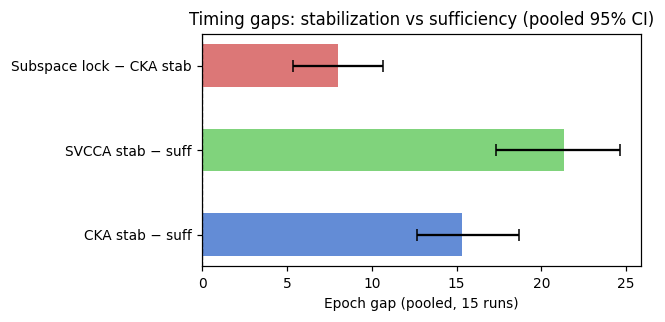

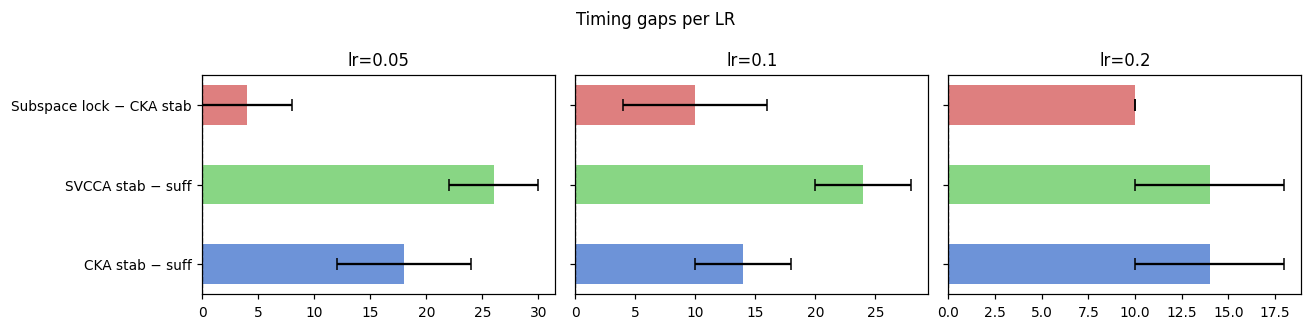

In [6]:
# ── forest / bar plot of pooled mean_gap with CI ─────────────────────────────
timing = load_agg('study_timing_tests.csv')
if timing is not None:
    pooled = timing[timing.group == 'pooled'].copy()
    if pooled.empty:
        print('[SKIP] no pooled rows in study_timing_tests')
    else:
        gap_labels = {'gap_cka': 'CKA stab − suff', 'gap_svcca': 'SVCCA stab − suff',
                      'gap_lock_vs_cka': 'Subspace lock − CKA stab'}
        gaps = [g for g in ['gap_cka', 'gap_svcca', 'gap_lock_vs_cka'] if g in pooled.gap.values]
        rows = pooled[pooled.gap.isin(gaps)].set_index('gap')

        fig, ax = plt.subplots(figsize=(6, 3))
        bar_colors = ['#4878CF', '#6ACC65', '#D65F5F']
        for i, g in enumerate(gaps):
            if g not in rows.index: continue
            r = rows.loc[g]
            ax.barh(i, r.mean_gap,
                    xerr=[[r.mean_gap - r.ci_lo], [r.ci_hi - r.mean_gap]],
                    color=bar_colors[i], capsize=4, alpha=0.85, height=0.5)
        ax.axvline(0, color='k', lw=0.8, ls='--')
        ax.set_yticks(list(range(len(gaps))))
        ax.set_yticklabels([gap_labels.get(g, g) for g in gaps])
        ax.set_xlabel('Epoch gap (pooled, 15 runs)')
        ax.set_title('Timing gaps: stabilization vs sufficiency (pooled 95% CI)')
        plt.tight_layout()
        plt.show()

        # per-LR sub-plots
        per_lr = timing[timing.group != 'pooled'].copy()
        lr_groups = sorted(per_lr.group.unique())
        if lr_groups:
            fig2, axes = plt.subplots(1, len(lr_groups), figsize=(4*len(lr_groups), 3), sharey=True)
            if len(lr_groups) == 1: axes = [axes]
            for ax2, grp in zip(axes, lr_groups):
                gdf = per_lr[per_lr.group == grp].set_index('gap')
                for i, g in enumerate(gaps):
                    if g not in gdf.index: continue
                    r = gdf.loc[g]
                    ax2.barh(i, r.mean_gap,
                             xerr=[[r.mean_gap - r.ci_lo], [r.ci_hi - r.mean_gap]],
                             color=bar_colors[i], capsize=4, alpha=0.80, height=0.5)
                ax2.axvline(0, color='k', lw=0.8, ls='--')
                ax2.set_title(grp)
                ax2.set_yticks(list(range(len(gaps))))
                ax2.set_yticklabels([gap_labels.get(g, g) for g in gaps])
            fig2.suptitle('Timing gaps per LR')
            plt.tight_layout()
            plt.show()

In [7]:
# ── study_milestones: full table + per-LR breakdown ─────────────────────────
ms = load_agg('study_milestones.csv')
if ms is not None:
    display(ms.round(2))

    print('\nPer-LR mean timing (averaged across 5 seeds):')
    timing_cols = safe_cols(ms, ['t_suff', 't_stab_cka', 't_sublock', 't_svcca'],
                            context='milestones per-LR')
    if timing_cols:
        per_lr_ms = ms.groupby('lr')[timing_cols].mean().round(1)
        display(per_lr_ms)

,run,lr,seed,probe_src,final_acc,t_suff,t_stab_cka,t_svcca,t_sublock,gap_cka,gap_svcca,gap_lock_vs_cka
0,final_lr005_seed0,0.05,0,logistic_regression,0.95,140.0,160.0,160.0,150.0,20.0,20.0,10.0
1,final_lr005_seed1,0.05,1,logistic_regression,0.95,140.0,160.0,170.0,160.0,20.0,30.0,0.0
2,final_lr005_seed2,0.05,2,logistic_regression,0.95,130.0,160.0,160.0,150.0,30.0,30.0,10.0
3,final_lr005_seed3,0.05,3,logistic_regression,0.95,140.0,150.0,170.0,150.0,10.0,30.0,0.0
4,final_lr005_seed42,0.05,42,logistic_regression,0.95,140.0,150.0,160.0,150.0,10.0,20.0,0.0
5,final_lr010_seed0,0.10,0,logistic_regression,0.96,160.0,170.0,180.0,170.0,10.0,20.0,0.0
6,final_lr010_seed1,0.10,1,logistic_regression,0.95,150.0,170.0,180.0,150.0,20.0,30.0,20.0
7,final_lr010_seed2,0.10,2,logistic_regression,0.96,150.0,170.0,180.0,160.0,20.0,30.0,10.0
8,final_lr010_seed3,0.10,3,logistic_regression,0.95,160.0,170.0,180.0,160.0,10.0,20.0,10.0
9,final_lr010_seed42,0.10,42,logistic_regression,0.96,160.0,170.0,180.0,160.0,10.0,20.0,10.0



Per-LR mean timing (averaged across 5 seeds):


,t_suff,t_stab_cka,t_sublock,t_svcca
lr,,,,
0.05,138.0,156.0,152.0,164.0
0.10,156.0,170.0,160.0,180.0
0.20,166.0,180.0,170.0,180.0


---
## Chapter 2 — Similarity Trajectories

Pregenerated figure (cluster-generated) followed by the from-scratch per-LR rebuild from `load_ext('similarity')`, `load_ext('probe_functional')`, and `load_ext('subspace')`.

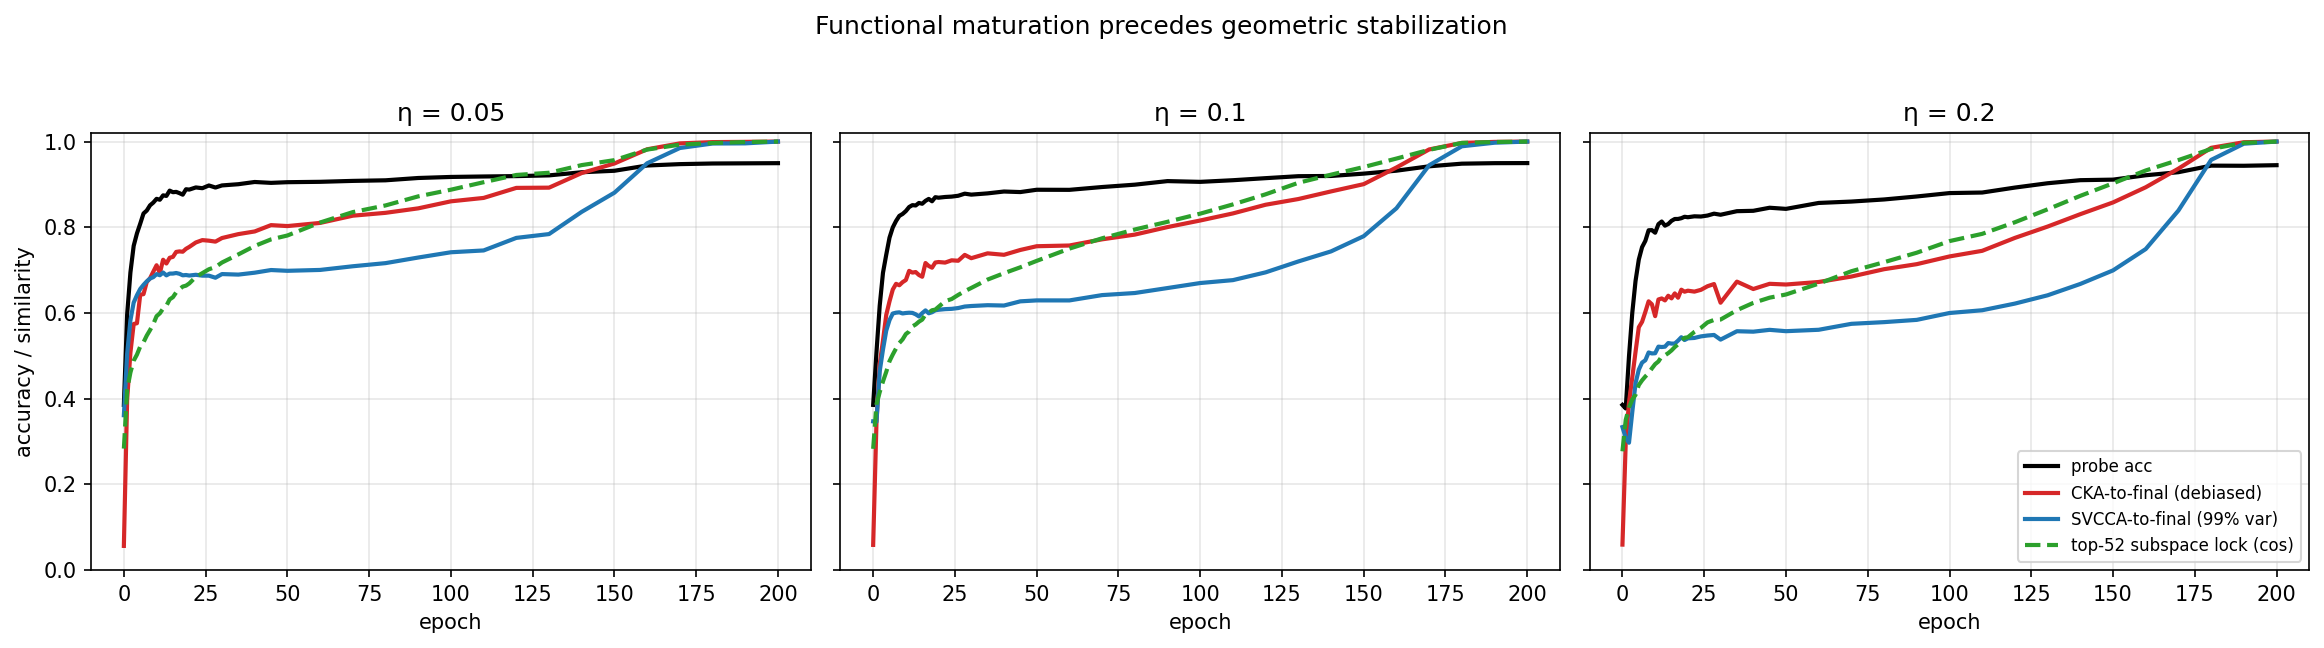

In [8]:
# ── pregenerated PNG (cluster-generated) ─────────────────────────────────────
show_png('fig_timing.png')

*From-scratch version (seed-averaged, all 15 runs)*

In [9]:
# ── Ch.2 seed-averaged table ────────────────────────────────────────────────
sim   = load_ext('similarity')
probe = load_ext('probe_functional')
sub_df = load_ext('subspace')

ch2_ok = all(df is not None for df in [sim, probe, sub_df])
if ch2_ok:
    # seed-average per (lr, epoch)
    sim_cols  = safe_cols(sim, ['cka_debiased_tofinal', 'svcca_tofinal'], 'similarity')
    prob_cols = safe_cols(probe, ['test_acc'], 'probe_functional')
    sub_lock  = sub_df[sub_df.k == LOCK_K].copy()
    sub_cols  = safe_cols(sub_lock, ['pa_mean_cos'], 'subspace')

    def gavg(df, by, cols):
        grp = df.groupby(by)[cols]
        mean = grp.mean().rename(columns={c: c+'_mean' for c in cols})
        std  = grp.std().rename(columns={c: c+'_std'  for c in cols})
        return mean.join(std).reset_index()

    sim_avg  = gavg(sim,      ['lr','epoch'], sim_cols)  if sim_cols  else None
    prob_avg = gavg(probe,    ['lr','epoch'], prob_cols) if prob_cols else None
    sub_avg  = gavg(sub_lock, ['lr','epoch'], sub_cols)  if sub_cols  else None

    merged = sim_avg
    if prob_avg is not None: merged = merged.merge(prob_avg, on=['lr','epoch'], how='left')
    if sub_avg  is not None: merged = merged.merge(sub_avg,  on=['lr','epoch'], how='left')

    rep_epochs = [e for e in [0,10,30,50,100,150,200] if e in merged.epoch.values]
    display(merged[merged.epoch.isin(rep_epochs)].round(3))
else:
    print('[SKIP] Ch.2: missing one or more ext CSVs')

,lr,epoch,cka_debiased_tofinal_mean,svcca_tofinal_mean,cka_debiased_tofinal_std,svcca_tofinal_std,test_acc_mean,test_acc_std,pa_mean_cos_mean,pa_mean_cos_std
0,0.05,0,0.056,0.361,0.011,0.031,0.385,0.004,0.284,0.004
10,0.05,10,0.711,0.691,0.017,0.005,0.866,0.004,0.592,0.004
25,0.05,30,0.775,0.691,0.015,0.010,0.898,0.006,0.718,0.007
29,0.05,50,0.803,0.698,0.014,0.009,0.905,0.006,0.781,0.004
34,0.05,100,0.861,0.742,0.006,0.012,0.917,0.006,0.888,0.006
39,0.05,150,0.949,0.881,0.004,0.011,0.932,0.003,0.957,0.004
44,0.05,200,1.000,1.000,0.000,0.000,0.950,0.003,1.000,0.000
45,0.10,0,0.059,0.347,0.011,0.034,0.385,0.004,0.283,0.007
55,0.10,10,0.677,0.600,0.025,0.011,0.838,0.005,0.551,0.021
70,0.10,30,0.728,0.616,0.033,0.010,0.876,0.006,0.658,0.021


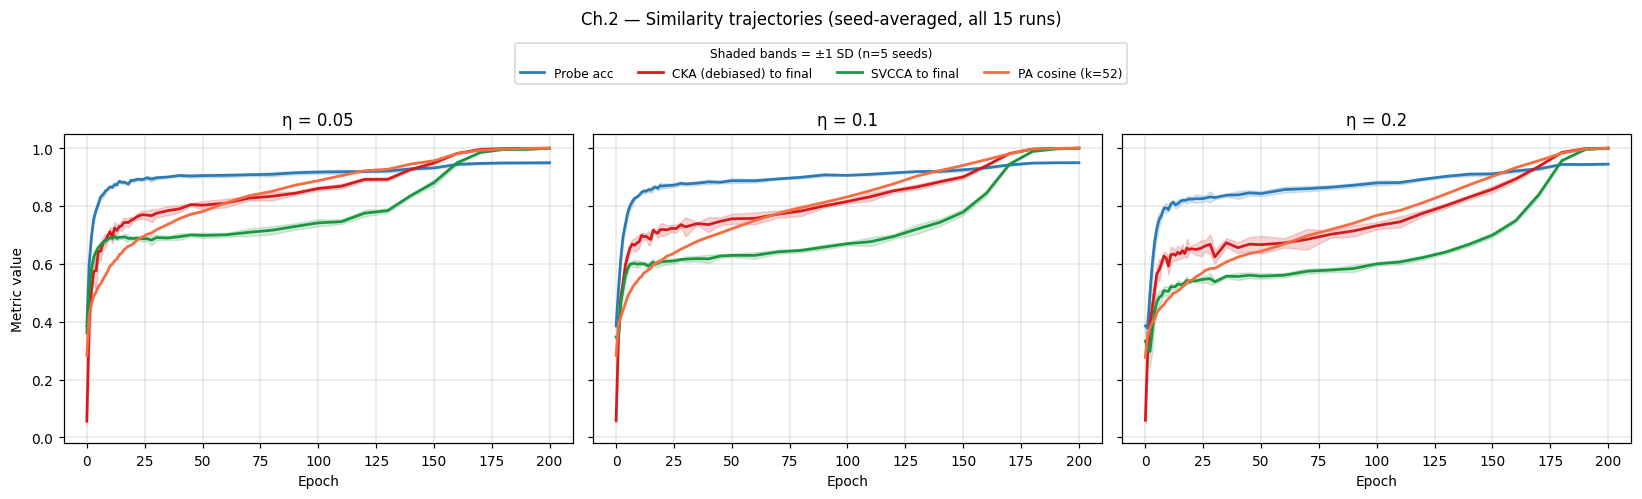

In [10]:
# ── Ch.2 from-scratch: 3 per-LR panels ─────────────────────────────────────
METRIC_COLORS = {
    'test_acc_mean':            '#2c7bb6',
    'cka_debiased_tofinal_mean':'#d7191c',
    'svcca_tofinal_mean':       '#1a9641',
    'pa_mean_cos_mean':         '#f46d43',
}
METRIC_LABELS = {
    'test_acc_mean':            'Probe acc',
    'cka_debiased_tofinal_mean':'CKA (debiased) to final',
    'svcca_tofinal_mean':       'SVCCA to final',
    'pa_mean_cos_mean':         f'PA cosine (k={LOCK_K})',
}

if ch2_ok:
    lrs = sorted(merged.lr.unique())
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
    plot_cols = [c for c in METRIC_LABELS if c in merged.columns]

    for ax, lr in zip(axes, lrs):
        d = merged[merged.lr == lr].sort_values('epoch')
        for mc in plot_cols:
            std_col = mc.replace('_mean', '_std')
            mn  = d[mc].values
            std = d[std_col].values if std_col in d.columns else np.zeros_like(mn)
            col = METRIC_COLORS[mc]
            ax.plot(d.epoch, mn, lw=1.8, color=col, label=METRIC_LABELS[mc])
            ax.fill_between(d.epoch, mn - std, mn + std, alpha=0.18, color=col)
        ax.set_title(f'η = {lr}')
        ax.set_xlabel('Epoch')
        ax.set_ylim(-0.02, 1.05)
        ax.grid(True, lw=0.3)
        if ax is axes[0]:
            ax.set_ylabel('Metric value')

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=len(plot_cols),
               fontsize=8, title='Shaded bands = ±1 SD (n=5 seeds)', title_fontsize=8,
               bbox_to_anchor=(0.5, 1.06))
    fig.suptitle('Ch.2 — Similarity trajectories (seed-averaged, all 15 runs)', y=1.12)
    plt.tight_layout()
    plt.show()

---
## Chapter 3 — Spectral Structure

Pregenerated figures followed by from-scratch plots from `load_ext('subspace')` and `load_ext('rank_accuracy')`, seed-averaged across 5 seeds per LR.

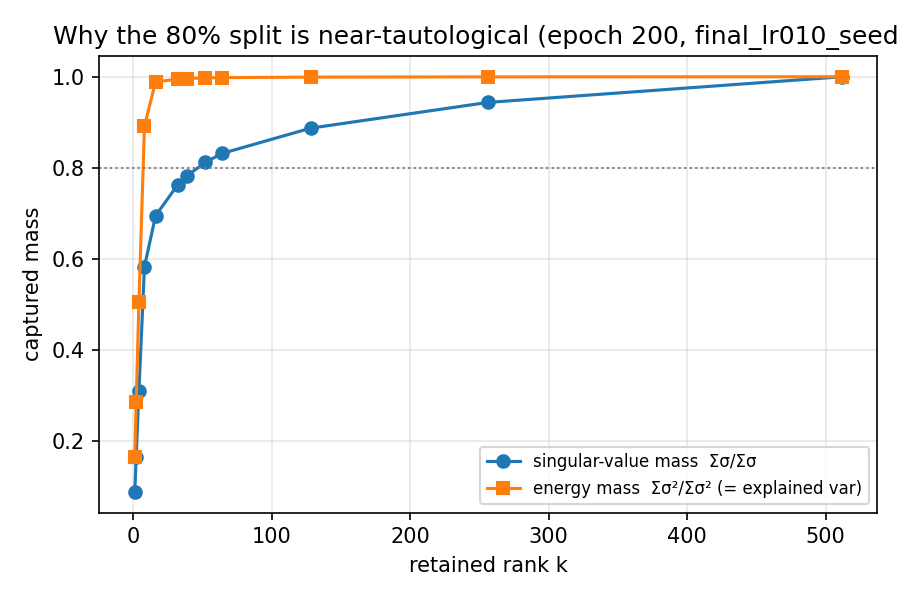

In [11]:
# ── pregenerated PNG ─────────────────────────────────────────────────────────
show_png('fig_spectral_mass.png')

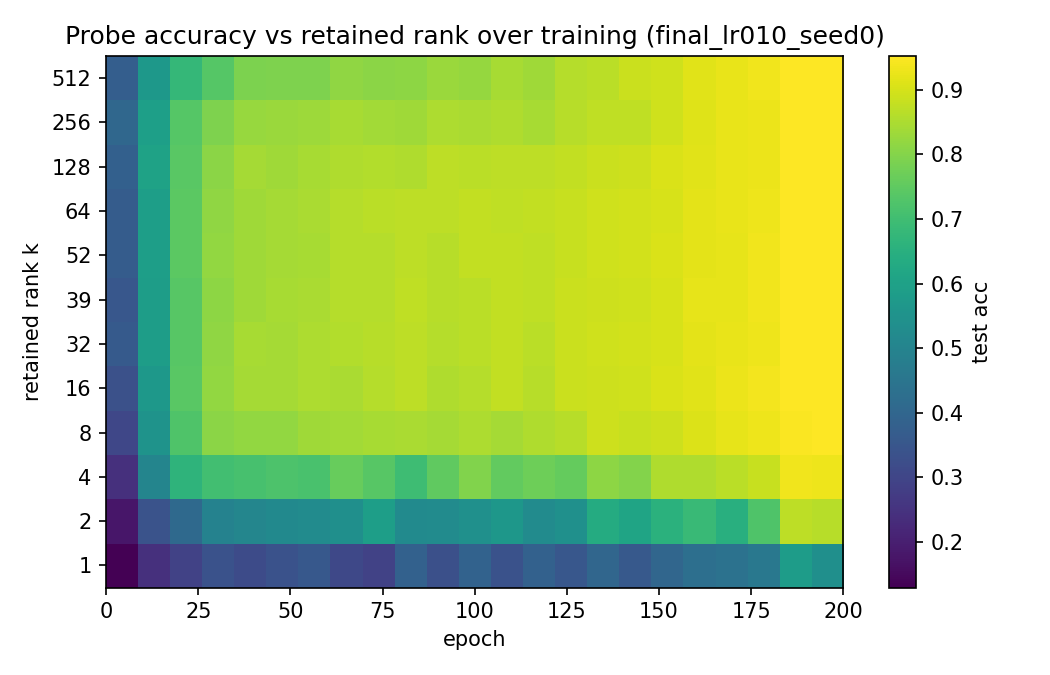

In [12]:
show_png('fig_rank_accuracy.png')

*From-scratch version (seed-averaged, all 15 runs)*

In [13]:
# ── Ch.3 spectral table: seed-avg sv_mass & energy_mass at final epoch ──────
sub_df = sub_df if 'sub_df' in dir() and sub_df is not None else load_ext('subspace')
if sub_df is not None:
    final_ep = sub_df.epoch.max()
    sub_final = sub_df[sub_df.epoch == final_ep].copy()
    spec_cols = safe_cols(sub_final, ['sv_mass', 'energy_mass'], 'spectral')
    if spec_cols:
        spec_avg = sub_final.groupby(['lr','k'])[spec_cols].agg(['mean','std']).round(3)
        spec_avg.columns = ['_'.join(c) for c in spec_avg.columns]
        display(spec_avg.reset_index())

,lr,k,sv_mass_mean,sv_mass_std,energy_mass_mean,energy_mass_std
0,0.05,1,0.092,0.001,0.160,0.002
1,0.05,2,0.171,0.001,0.278,0.002
2,0.05,4,0.323,0.001,0.500,0.000
3,0.05,8,0.611,0.001,0.895,0.001
4,0.05,16,0.720,0.001,0.991,0.000
5,0.05,32,0.782,0.001,0.996,0.000
6,0.05,39,0.801,0.001,0.997,0.000
7,0.05,52,0.829,0.001,0.998,0.000
8,0.05,64,0.848,0.001,0.999,0.000
9,0.05,128,0.898,0.002,0.999,0.000


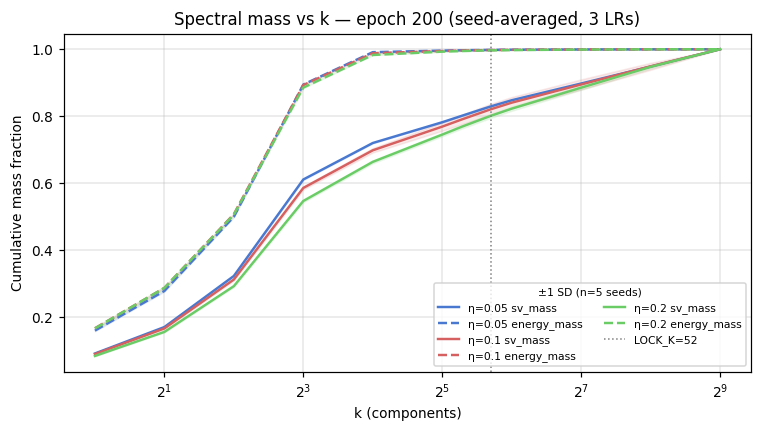

In [14]:
# ── Ch.3 sv_mass vs energy_mass vs k at final epoch, seed-averaged per LR ──
if sub_df is not None:
    final_ep = sub_df.epoch.max()
    sub_final = sub_df[sub_df.epoch == final_ep].copy()
    spec_cols = safe_cols(sub_final, ['sv_mass', 'energy_mass'], 'spectral')
    if spec_cols:
        avg = sub_final.groupby(['lr','k'])[spec_cols].mean().reset_index()
        std = sub_final.groupby(['lr','k'])[spec_cols].std().reset_index()

        fig, ax = plt.subplots(figsize=(7, 4))
        ls_map = {'sv_mass': '-', 'energy_mass': '--'}
        for lr in sorted(avg.lr.unique()):
            d = avg[avg.lr == lr].sort_values('k')
            s = std[std.lr == lr].sort_values('k')
            c = LR_COLORS[lr]
            for col in spec_cols:
                mn = d[col].values
                sd = s[col].values
                ax.plot(d.k, mn, ls=ls_map[col], lw=1.6, color=c,
                        label=f'η={lr} {col}')
                ax.fill_between(d.k, mn-sd, mn+sd, alpha=0.12, color=c)
        ax.set_xlabel('k (components)')
        ax.set_ylabel('Cumulative mass fraction')
        ax.set_xscale('log', base=2)
        ax.set_title(f'Spectral mass vs k — epoch {final_ep} (seed-averaged, 3 LRs)')
        ax.axvline(LOCK_K, color='gray', ls=':', lw=1, label=f'LOCK_K={LOCK_K}')
        ax.legend(fontsize=7, ncol=2, title='±1 SD (n=5 seeds)', title_fontsize=7)
        ax.grid(True, lw=0.3)
        plt.tight_layout()
        plt.show()

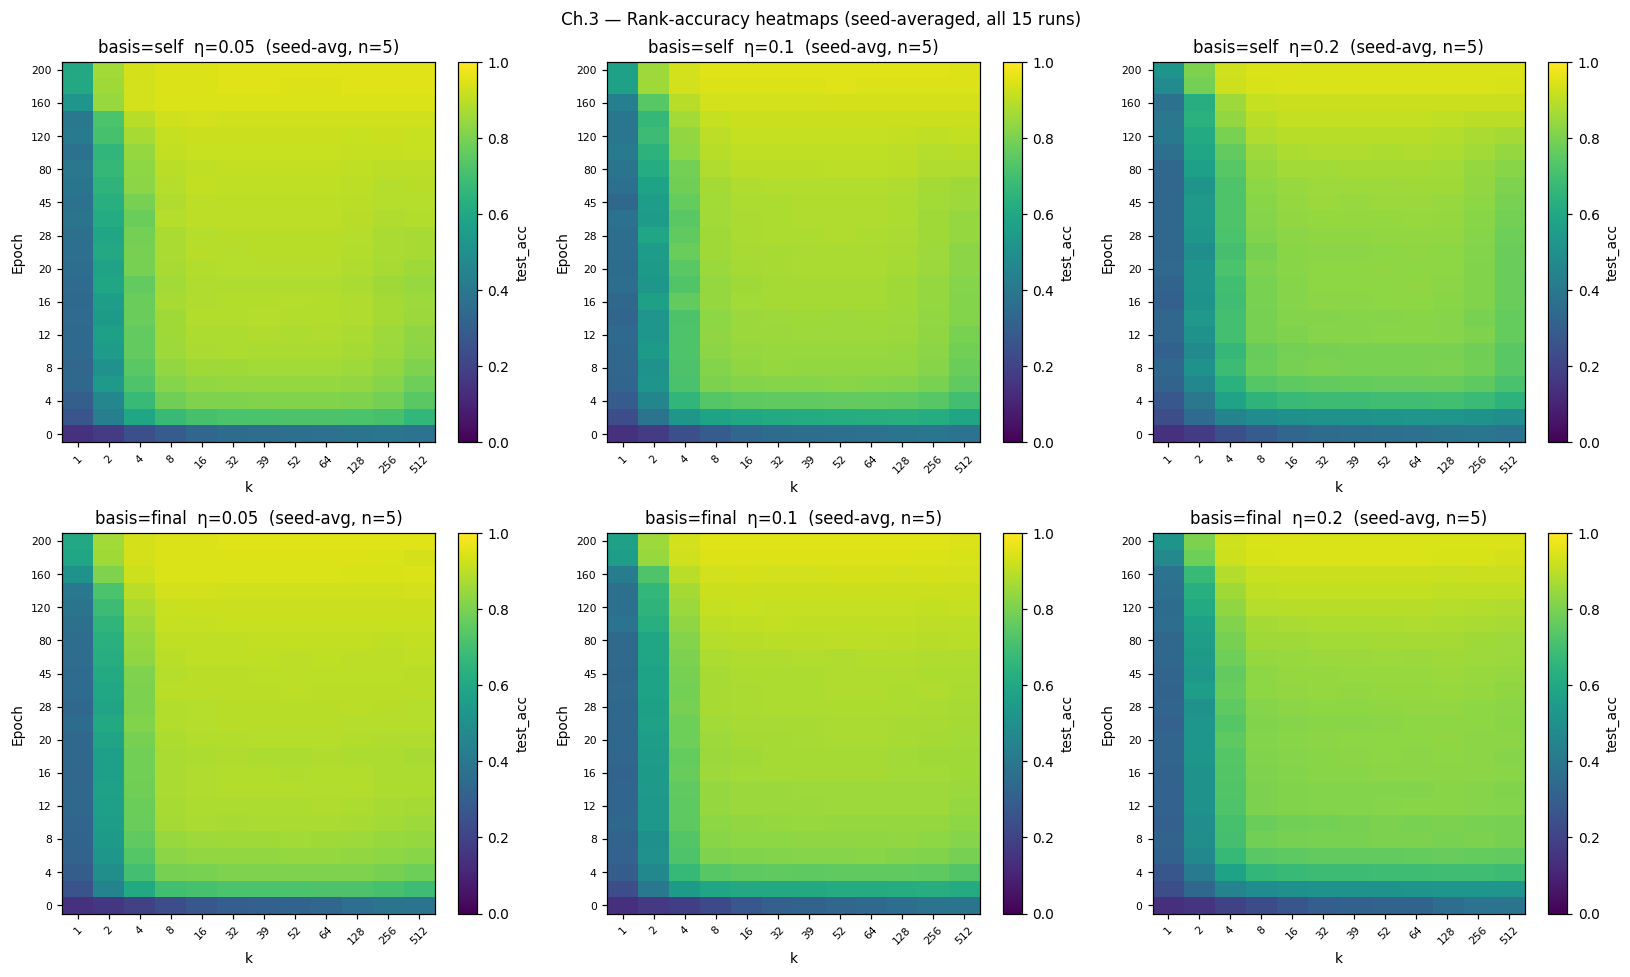

In [15]:
# ── Ch.3 rank-accuracy heatmaps: 2 rows (basis) × 3 cols (LR) ───────────────
ra = load_ext('rank_accuracy')
if ra is not None:
    lrs = sorted(ra.lr.unique())
    bases = ['self', 'final']
    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    for row_i, basis in enumerate(bases):
        bd = ra[ra.basis == basis]
        for col_i, lr in enumerate(lrs):
            ax = axes[row_i, col_i]
            d = bd[bd.lr == lr]
            if d.empty:
                ax.axis('off'); continue
            # seed-average test_acc per (epoch, k)
            if 'test_acc' not in d.columns:
                print(f'[SKIP] test_acc not in rank_accuracy (basis={basis}, lr={lr})')
                ax.axis('off'); continue
            pivot = d.groupby(['epoch','k'])['test_acc'].mean().unstack('k')
            epochs_s = sorted(pivot.index)
            ks_s     = sorted(pivot.columns)
            mat = pivot.loc[epochs_s, ks_s].values

            im = ax.imshow(mat, aspect='auto', origin='lower', cmap='viridis',
                           vmin=0, vmax=1)
            ax.set_xticks(range(len(ks_s)))
            ax.set_xticklabels(ks_s, rotation=45, fontsize=7)
            tick_step = max(1, len(epochs_s)//10)
            ax.set_yticks(range(0, len(epochs_s), tick_step))
            ax.set_yticklabels([epochs_s[i] for i in range(0, len(epochs_s), tick_step)], fontsize=7)
            ax.set_xlabel('k')
            ax.set_ylabel('Epoch')
            ax.set_title(f'basis={basis}  η={lr}  (seed-avg, n=5)')
            plt.colorbar(im, ax=ax, label='test_acc')

    fig.suptitle('Ch.3 — Rank-accuracy heatmaps (seed-averaged, all 15 runs)', fontsize=11)
    plt.tight_layout()
    plt.show()

---
## Chapter 4 — Subspace Dynamics

Principal-angle convergence and component-wise CKA from `load_ext('subspace')`, seed-averaged per LR.

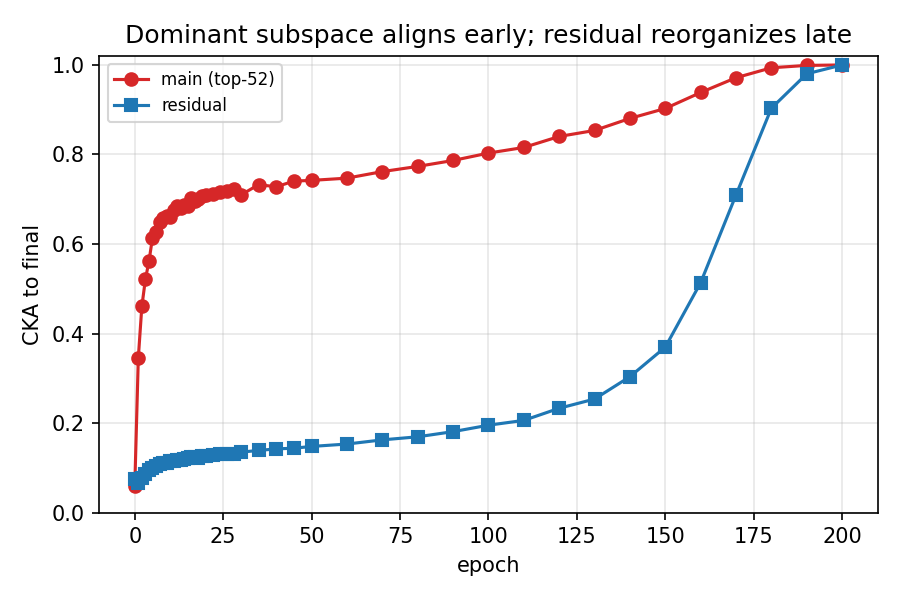

In [16]:
# ── pregenerated PNG ─────────────────────────────────────────────────────────
show_png('fig_component_cka.png')

*From-scratch version (seed-averaged, all 15 runs)*

In [17]:
# ── Ch.4 subspace table at LOCK_K (representative epochs) ──────────────────
sub_df = sub_df if 'sub_df' in dir() and sub_df is not None else load_ext('subspace')
if sub_df is not None:
    sub_lock = sub_df[sub_df.k == LOCK_K].copy()
    if sub_lock.empty:
        print(f'[SKIP] LOCK_K={LOCK_K} not found in subspace k values: {sorted(sub_df.k.unique())}')
    else:
        s_cols = safe_cols(sub_lock, ['pa_mean_cos','pa_min_cos','cka_main_tofinal','cka_resid_tofinal'], 'subspace')
        avg = sub_lock.groupby(['lr','epoch'])[s_cols].agg(['mean','std']).round(3)
        avg.columns = ['_'.join(c) for c in avg.columns]
        rep_epochs = [e for e in [0,10,30,50,100,150,200] if e in sub_lock.epoch.values]
        display(avg.reset_index()[avg.reset_index().epoch.isin(rep_epochs)])

,lr,epoch,pa_mean_cos_mean,pa_mean_cos_std,pa_min_cos_mean,pa_min_cos_std,cka_main_tofinal_mean,cka_main_tofinal_std,cka_resid_tofinal_mean,cka_resid_tofinal_std
0,0.05,0,0.284,0.004,0.005,0.005,0.058,0.011,0.075,0.003
10,0.05,10,0.592,0.004,0.016,0.012,0.712,0.017,0.130,0.006
25,0.05,30,0.718,0.007,0.029,0.024,0.775,0.014,0.160,0.009
29,0.05,50,0.781,0.004,0.063,0.050,0.803,0.014,0.180,0.009
34,0.05,100,0.888,0.006,0.103,0.080,0.861,0.006,0.251,0.010
39,0.05,150,0.957,0.004,0.190,0.092,0.949,0.004,0.491,0.026
44,0.05,200,1.000,0.000,1.000,0.000,1.000,0.000,1.000,0.000
45,0.10,0,0.283,0.007,0.002,0.001,0.060,0.011,0.074,0.007
55,0.10,10,0.551,0.021,0.014,0.011,0.678,0.025,0.115,0.017
70,0.10,30,0.658,0.021,0.017,0.013,0.728,0.033,0.134,0.023


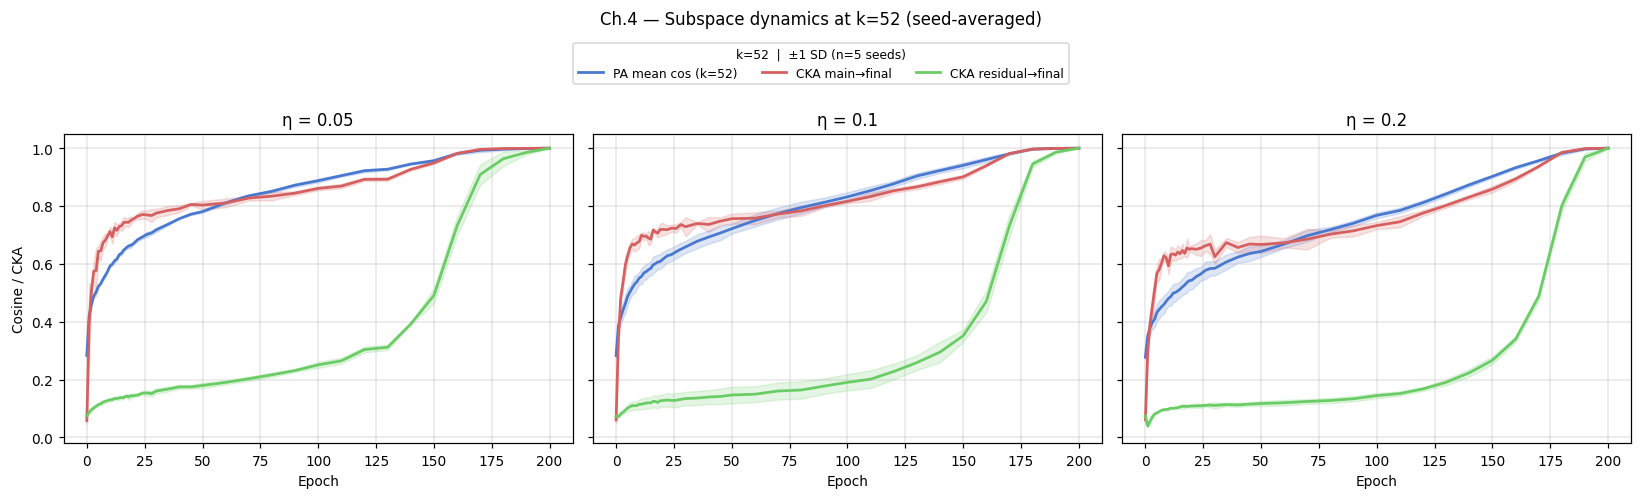

In [18]:
# ── Ch.4 pa_mean_cos + component CKA vs epoch at LOCK_K (3 panels by LR) ──
if sub_df is not None:
    sub_lock = sub_df[sub_df.k == LOCK_K].copy()
    if not sub_lock.empty:
        s_cols = safe_cols(sub_lock, ['pa_mean_cos','cka_main_tofinal','cka_resid_tofinal'], 'Ch4')
        avg = sub_lock.groupby(['lr','epoch'])[s_cols].mean().reset_index()
        std = sub_lock.groupby(['lr','epoch'])[s_cols].std().reset_index()

        M_COLORS = {'pa_mean_cos':'#4878CF',
                    'cka_main_tofinal':'#D65F5F',
                    'cka_resid_tofinal':'#6ACC65'}
        M_LABELS = {'pa_mean_cos': f'PA mean cos (k={LOCK_K})',
                    'cka_main_tofinal': 'CKA main→final',
                    'cka_resid_tofinal': 'CKA residual→final'}

        lrs = sorted(avg.lr.unique())
        fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
        for ax, lr in zip(axes, lrs):
            da = avg[avg.lr == lr].sort_values('epoch')
            ds = std[std.lr == lr].sort_values('epoch')
            for col in s_cols:
                mn = da[col].values
                sd = ds[col].values if col in ds.columns else np.zeros_like(mn)
                c  = M_COLORS.get(col, 'k')
                ax.plot(da.epoch, mn, lw=1.8, color=c, label=M_LABELS.get(col, col))
                ax.fill_between(da.epoch, mn-sd, mn+sd, alpha=0.18, color=c)
            ax.set_title(f'η = {lr}')
            ax.set_xlabel('Epoch')
            ax.set_ylim(-0.02, 1.05)
            ax.grid(True, lw=0.3)
            if ax is axes[0]: ax.set_ylabel('Cosine / CKA')

        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc='upper center', ncol=3, fontsize=8,
                   title=f'k={LOCK_K}  |  ±1 SD (n=5 seeds)', title_fontsize=8,
                   bbox_to_anchor=(0.5, 1.06))
        fig.suptitle(f'Ch.4 — Subspace dynamics at k={LOCK_K} (seed-averaged)', y=1.12)
        plt.tight_layout()
        plt.show()

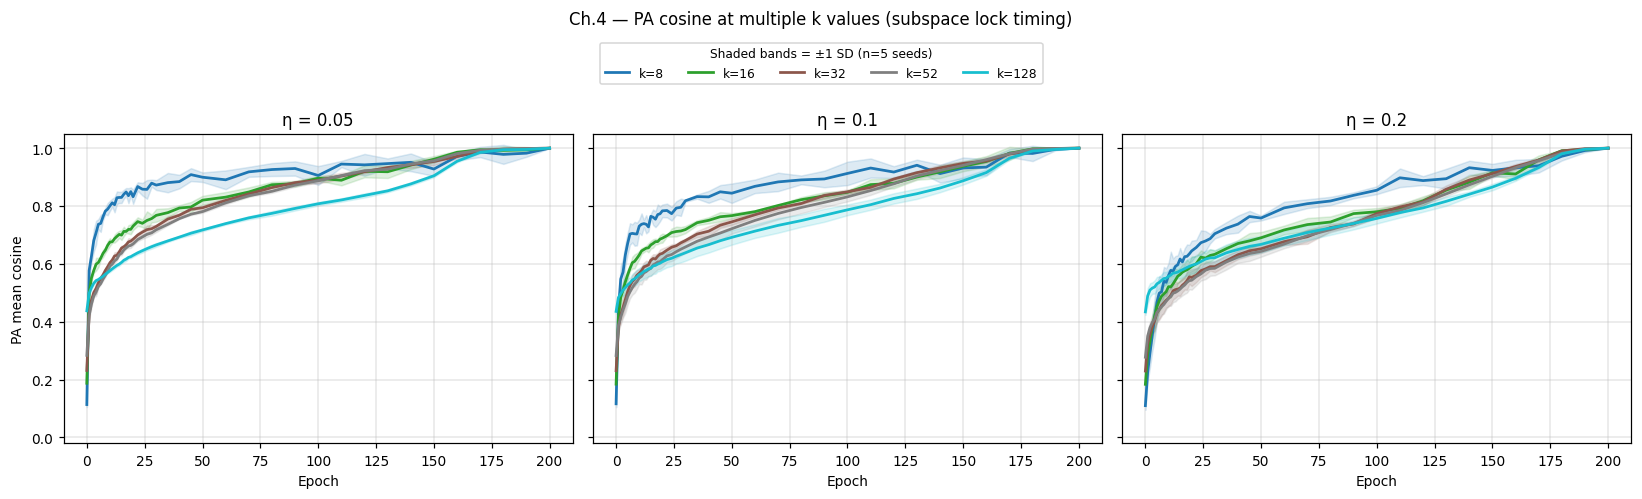

In [19]:
# ── Ch.4 pa_mean_cos at multiple k values, seed-averaged per LR (3 panels) ──
if sub_df is not None:
    K_PLOT = [k for k in [8, 16, 32, 52, 128] if k in sub_df.k.unique()]
    sub_multi = sub_df[sub_df.k.isin(K_PLOT)].copy()
    avg_multi  = sub_multi.groupby(['lr','epoch','k'])['pa_mean_cos'].mean().reset_index()
    std_multi  = sub_multi.groupby(['lr','epoch','k'])['pa_mean_cos'].std().reset_index()

    lrs = sorted(avg_multi.lr.unique())
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
    k_cmap = cm.get_cmap('tab10', len(K_PLOT))
    for ax, lr in zip(axes, lrs):
        for i, k in enumerate(K_PLOT):
            da = avg_multi[(avg_multi.lr == lr) & (avg_multi.k == k)].sort_values('epoch')
            ds = std_multi[(std_multi.lr == lr) & (std_multi.k == k)].sort_values('epoch')
            if da.empty: continue
            mn = da['pa_mean_cos'].values
            sd = ds['pa_mean_cos'].values if not ds.empty else np.zeros_like(mn)
            c = k_cmap(i)
            ax.plot(da.epoch, mn, lw=1.8, color=c, label=f'k={k}')
            ax.fill_between(da.epoch, mn-sd, mn+sd, alpha=0.15, color=c)
        ax.set_title(f'η = {lr}')
        ax.set_xlabel('Epoch')
        ax.set_ylim(-0.02, 1.05)
        ax.grid(True, lw=0.3)
        if ax is axes[0]: ax.set_ylabel('PA mean cosine')

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=len(K_PLOT), fontsize=8,
               title='Shaded bands = ±1 SD (n=5 seeds)', title_fontsize=8,
               bbox_to_anchor=(0.5, 1.06))
    fig.suptitle('Ch.4 — PA cosine at multiple k values (subspace lock timing)', y=1.12)
    plt.tight_layout()
    plt.show()

---
## Chapter 5 — Functional Metrics & Fisher

Fisher information and probe performance from `load_ext('fisher')` and `load_ext('probe_functional')`, seed-averaged per LR.

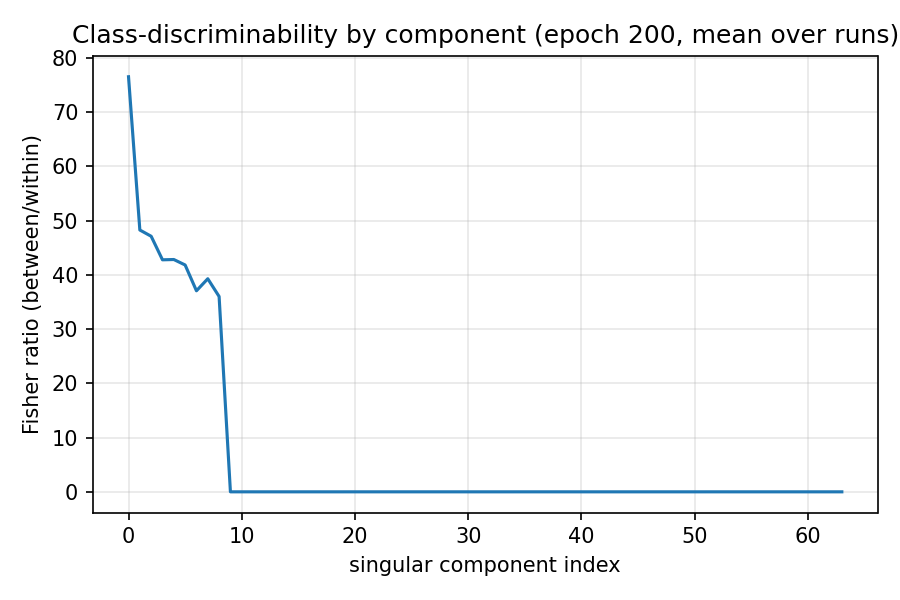

In [20]:
# ── pregenerated PNG ─────────────────────────────────────────────────────────
show_png('fig_fisher.png')

*From-scratch version (seed-averaged, all 15 runs)*

In [21]:
# ── Ch.5 Fisher table at final epoch ────────────────────────────────────────
fish = load_ext('fisher')
if fish is not None:
    final_ep = fish.epoch.max()
    fish_final = fish[fish.epoch == final_ep].copy()
    f_cols = safe_cols(fish_final, ['fisher', 'sing_val'], 'fisher')
    if f_cols:
        fish_avg = fish_final.groupby(['lr','component'])[f_cols].agg(['mean','std']).round(4)
        fish_avg.columns = ['_'.join(c) for c in fish_avg.columns]
        display(fish_avg.reset_index().head(30))

,lr,component,fisher_mean,fisher_std,sing_val_mean,sing_val_std
0,0.05,0,116.9951,5.1564,435.3675,2.4140
1,0.05,1,73.8766,2.2806,374.8499,1.2547
2,0.05,2,72.5722,1.8334,370.2836,2.2996
3,0.05,3,67.1574,2.1212,354.2972,2.8492
4,0.05,4,67.3982,6.2319,351.1744,1.3099
5,0.05,5,66.1775,3.7782,344.2802,0.5078
6,0.05,6,54.0395,2.8360,337.6307,1.4756
7,0.05,7,61.5304,4.6854,334.9417,2.0163
8,0.05,8,54.1530,4.2311,330.9093,2.3052
9,0.05,9,0.0003,0.0001,33.1226,0.9745


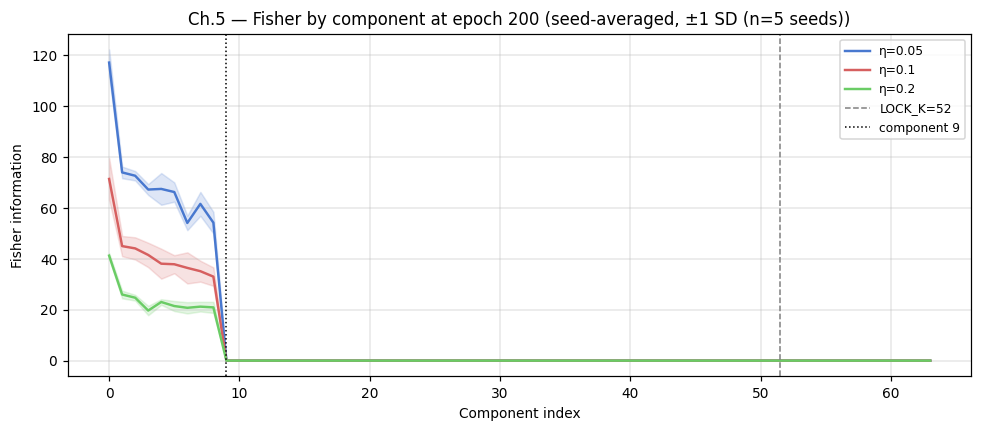

In [22]:
# ── Ch.5 Fisher by component at final epoch: 3 overlaid lines ──────────────
if fish is not None:
    final_ep = fish.epoch.max()
    fish_final = fish[fish.epoch == final_ep].copy()
    if 'fisher' not in fish_final.columns:
        print('[SKIP] fisher column not found')
    else:
        avg = fish_final.groupby(['lr','component'])['fisher'].mean().reset_index()
        std = fish_final.groupby(['lr','component'])['fisher'].std().reset_index()

        n_comp_show = 64
        fig, ax = plt.subplots(figsize=(9, 4))
        for lr in sorted(avg.lr.unique()):
            da = avg[avg.lr == lr].sort_values('component').head(n_comp_show)
            ds = std[std.lr == lr].sort_values('component').head(n_comp_show)
            mn = da['fisher'].values
            sd = ds['fisher'].values if not ds.empty else np.zeros_like(mn)
            c  = LR_COLORS[lr]
            ax.plot(da.component, mn, lw=1.6, color=c, label=f'η={lr}')
            ax.fill_between(da.component, mn-sd, mn+sd, alpha=0.18, color=c)
        ax.axvline(LOCK_K - 0.5, color='gray', ls='--', lw=1, label=f'LOCK_K={LOCK_K}')
        ax.axvline(N_CLASSES - 1, color='k', ls=':', lw=1, label=f'component {N_CLASSES-1}')
        ax.set_xlabel('Component index')
        ax.set_ylabel('Fisher information')
        ax.set_title(f'Ch.5 — Fisher by component at epoch {final_ep} (seed-averaged, ±1 SD (n=5 seeds))')
        ax.legend(fontsize=8)
        ax.grid(True, lw=0.3)
        plt.tight_layout()
        plt.show()

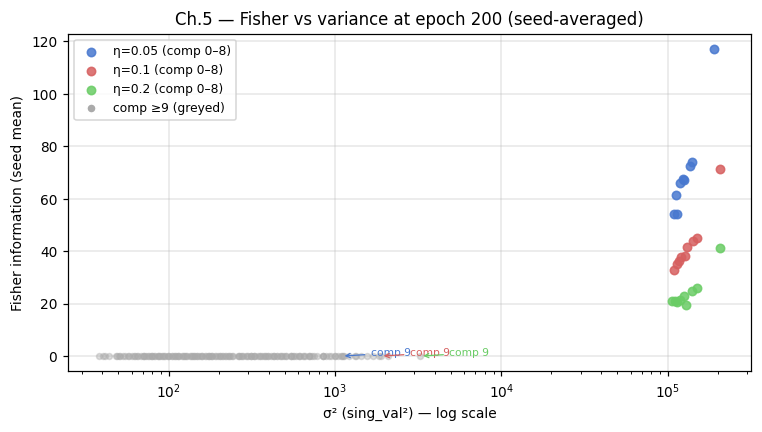

In [23]:
# ── Ch.5 Fisher-vs-variance scatter (sing_val^2 as σ²) ─────────────────────
if fish is not None:
    final_ep = fish.epoch.max()
    fish_final = fish[fish.epoch == final_ep].copy()
    need = safe_cols(fish_final, ['fisher', 'sing_val'], 'Fisher-vs-variance')
    if len(need) == 2:
        # seed-mean per (lr, component)
        fmean = fish_final.groupby(['lr','component'])[['fisher','sing_val']].mean().reset_index()
        fmean['sigma2'] = fmean['sing_val'] ** 2

        fig, ax = plt.subplots(figsize=(7, 4))
        for lr in sorted(fmean.lr.unique()):
            d = fmean[fmean.lr == lr].sort_values('component')
            c = LR_COLORS[lr]
            # highlighted: components 0..N_CLASSES-2
            hi = d[d.component <= N_CLASSES - 2]
            lo = d[d.component >  N_CLASSES - 2]
            ax.scatter(lo.sigma2, lo.fisher, color='#aaaaaa', s=15, alpha=0.4, zorder=2)
            ax.scatter(hi.sigma2, hi.fisher, color=c, s=30, alpha=0.85, zorder=3,
                       label=f'η={lr} (comp 0–{N_CLASSES-2})')
            # annotate component N_CLASSES-1
            c9 = d[d.component == N_CLASSES - 1]
            if not c9.empty:
                ax.annotate(f'comp {N_CLASSES-1}',
                            xy=(c9.sigma2.values[0], c9.fisher.values[0]),
                            xytext=(c9.sigma2.values[0]*1.5, c9.fisher.values[0]*1.1),
                            fontsize=7, color=c,
                            arrowprops=dict(arrowstyle='->', color=c, lw=0.8))
        ax.set_xscale('log')
        ax.set_xlabel('σ² (sing_val²) — log scale')
        ax.set_ylabel('Fisher information (seed mean)')
        ax.set_title(f'Ch.5 — Fisher vs variance at epoch {final_ep} (seed-averaged)')
        ax.legend(fontsize=8)
        ax.grid(True, lw=0.3)
        # grey legend entry
        from matplotlib.lines import Line2D
        ax.legend(handles=ax.get_legend_handles_labels()[0] +
                  [Line2D([0],[0],marker='o',color='w',markerfacecolor='#aaaaaa',
                           markersize=6,label=f'comp ≥{N_CLASSES-1} (greyed)')],
                  labels=ax.get_legend_handles_labels()[1]+[f'comp ≥{N_CLASSES-1} (greyed)'],
                  fontsize=8)
        plt.tight_layout()
        plt.show()

,lr,epoch,test_acc,test_nll,test_margin
0,0.05,0,0.3855,1.8027,-0.5822
10,0.05,10,0.8664,0.5009,7.1289
25,0.05,30,0.8976,0.3834,8.2419
29,0.05,50,0.9052,0.3696,8.8180
34,0.05,100,0.9175,0.3981,10.7149
39,0.05,150,0.9319,0.5452,14.2663
44,0.05,200,0.9496,0.2360,8.7103
45,0.10,0,0.3855,1.8027,-0.5822
55,0.10,10,0.8378,0.5445,5.2205
70,0.10,30,0.8762,0.4347,6.6287


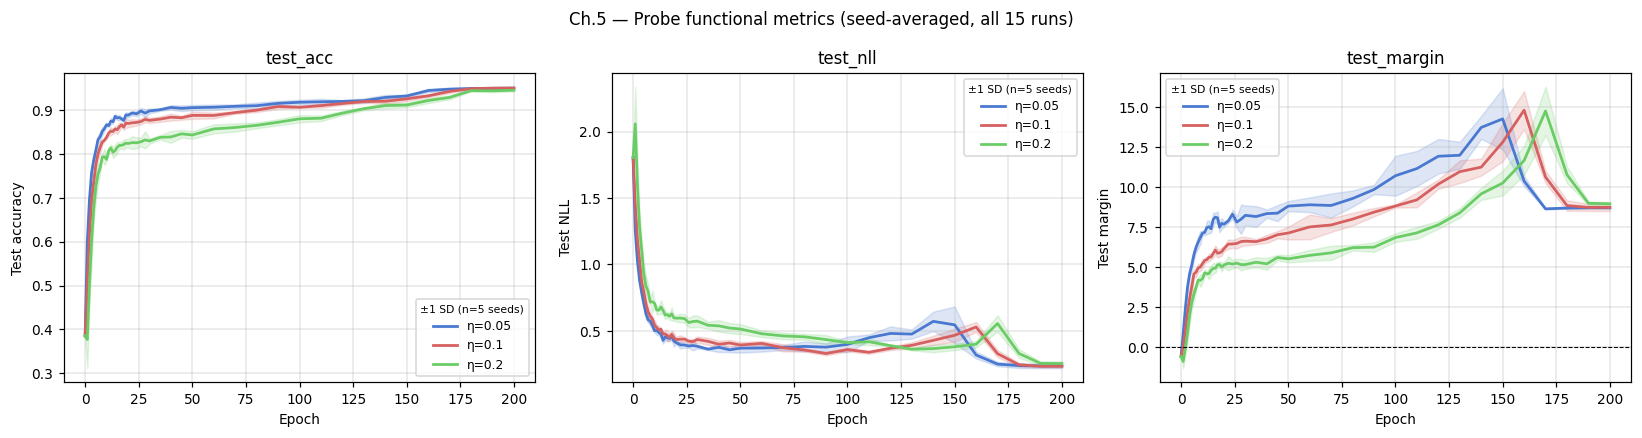

In [24]:
# ── Ch.5 probe functional trajectories: 3 panels (one per metric) ───────────
probe = probe if 'probe' in dir() and probe is not None else load_ext('probe_functional')
if probe is not None:
    func_cols = safe_cols(probe, ['test_acc','test_nll','test_margin'], 'probe_functional')
    if func_cols:
        avg_pf = probe.groupby(['lr','epoch'])[func_cols].mean().reset_index()
        std_pf = probe.groupby(['lr','epoch'])[func_cols].std().reset_index()

        # Table
        rep_ep = [e for e in [0,10,30,50,100,150,200] if e in avg_pf.epoch.values]
        display(avg_pf[avg_pf.epoch.isin(rep_ep)].round(4))

        # 3 panels by metric
        ylabels = {'test_acc':'Test accuracy','test_nll':'Test NLL','test_margin':'Test margin'}
        fig, axes = plt.subplots(1, len(func_cols), figsize=(5*len(func_cols), 4))
        if len(func_cols) == 1: axes = [axes]
        for ax, col in zip(axes, func_cols):
            for lr in sorted(avg_pf.lr.unique()):
                da = avg_pf[avg_pf.lr == lr].sort_values('epoch')
                ds = std_pf[std_pf.lr == lr].sort_values('epoch')
                mn = da[col].values
                sd = ds[col].values if col in ds.columns else np.zeros_like(mn)
                c  = LR_COLORS[lr]
                ax.plot(da.epoch, mn, lw=1.8, color=c, label=f'η={lr}')
                ax.fill_between(da.epoch, mn-sd, mn+sd, alpha=0.18, color=c)
            if col == 'test_margin':
                ax.axhline(0, color='k', lw=0.7, ls='--')
            ax.set_xlabel('Epoch')
            ax.set_ylabel(ylabels.get(col, col))
            ax.set_title(col)
            ax.legend(fontsize=8, title='±1 SD (n=5 seeds)', title_fontsize=7)
            ax.grid(True, lw=0.3)
        fig.suptitle('Ch.5 — Probe functional metrics (seed-averaged, all 15 runs)')
        plt.tight_layout()
        plt.show()

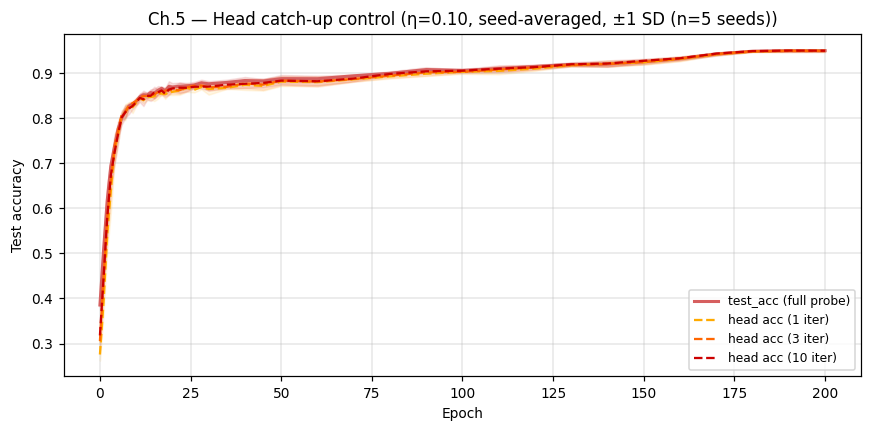

In [25]:
# ── Ch.5 head catch-up control for η=0.10 ───────────────────────────────────
if probe is not None:
    probe_010 = probe[probe.lr == 0.10].copy()
    head_cols = safe_cols(probe_010, ['head_acc_iter1','head_acc_iter3','head_acc_iter10'],
                          'head catch-up')
    if 'test_acc' in probe_010.columns:
        avg_010 = probe_010.groupby('epoch')[['test_acc'] + head_cols].mean().reset_index()
        std_010 = probe_010.groupby('epoch')[['test_acc'] + head_cols].std().reset_index()

        fig, ax = plt.subplots(figsize=(8, 4))
        mn = avg_010['test_acc'].values
        sd = std_010['test_acc'].values
        ax.plot(avg_010.epoch, mn, lw=2, color=LR_COLORS[0.10], label='test_acc (full probe)')
        ax.fill_between(avg_010.epoch, mn-sd, mn+sd, alpha=0.18, color=LR_COLORS[0.10])

        head_colors = ['#FFAA00','#FF6600','#CC0000']
        head_labels = {'head_acc_iter1':'head acc (1 iter)',
                       'head_acc_iter3':'head acc (3 iter)',
                       'head_acc_iter10':'head acc (10 iter)'}
        for hc, hcol in zip(head_cols, head_colors):
            mn_h = avg_010[hc].values
            sd_h = std_010[hc].values if hc in std_010.columns else np.zeros_like(mn_h)
            ax.plot(avg_010.epoch, mn_h, lw=1.5, ls='--', color=hcol,
                    label=head_labels.get(hc, hc))
            ax.fill_between(avg_010.epoch, mn_h-sd_h, mn_h+sd_h, alpha=0.1, color=hcol)

        ax.set_xlabel('Epoch')
        ax.set_ylabel('Test accuracy')
        ax.set_title('Ch.5 — Head catch-up control (η=0.10, seed-averaged, ±1 SD (n=5 seeds))')
        ax.legend(fontsize=8)
        ax.grid(True, lw=0.3)
        plt.tight_layout()
        plt.show()
    else:
        print('[SKIP] test_acc not found in probe_functional')

---
## Chapter 6 — Threshold Robustness

The full sweep requires all 15 runs (cluster-only). Results are hardcoded from the pooled run.

**Key insight:** `gap_cka` changes sign depending on the CKA threshold (tighter threshold → larger gap; loose threshold → CKA fires early, negative gap). `gap_lock_vs_cka` stays positive across all thresholds, confirming that subspace lock precedes CKA stabilization robustly.

In [26]:
# ── check for saved sweep table first ────────────────────────────────────────
sweep_candidates = glob.glob(os.path.join(ROOT, 'thesis_results', '**', '*sweep*'), recursive=True)
sweep_df = None
for p in sweep_candidates:
    if p.endswith('.csv'):
        print('Found saved sweep table:', p)
        sweep_df = pd.read_csv(p)
        display(sweep_df.round(4))
        break

if sweep_df is None:
    print('No saved sweep table found — using hardcoded pooled results.')

No saved sweep table found — using hardcoded pooled results.


In [27]:
# ── hardcoded pooled threshold-sweep results ──────────────────────────────────
if sweep_df is None:
    sweep_rows = [
        (0.90, 1, -15.33,  5.33, -6.67),
        (0.90, 2,   0.67, 21.33, -6.67),
        (0.90, 5,  83.20,103.87, -6.67),
        (0.95, 1,  -0.67,  5.33,  8.00),
        (0.95, 2,  15.33, 21.33,  8.00),
        (0.95, 5,  97.87,103.87,  8.00),
        (0.99, 1,  10.67,  5.33, 19.33),
        (0.99, 2,  26.67, 21.33, 19.33),
        (0.99, 5, 109.20,103.87, 19.33),
    ]
    sweep_df = pd.DataFrame(sweep_rows,
                            columns=['cka_thresh','delta_pp','gap_cka','gap_svcca','gap_lock_vs_cka'])
    print('Hardcoded pooled threshold-sweep table:')
    display(sweep_df.round(2))

Hardcoded pooled threshold-sweep table:


,cka_thresh,delta_pp,gap_cka,gap_svcca,gap_lock_vs_cka
0,0.90,1,-15.33,5.33,-6.67
1,0.90,2,0.67,21.33,-6.67
2,0.90,5,83.20,103.87,-6.67
3,0.95,1,-0.67,5.33,8.00
4,0.95,2,15.33,21.33,8.00
5,0.95,5,97.87,103.87,8.00
6,0.99,1,10.67,5.33,19.33
7,0.99,2,26.67,21.33,19.33
8,0.99,5,109.20,103.87,19.33


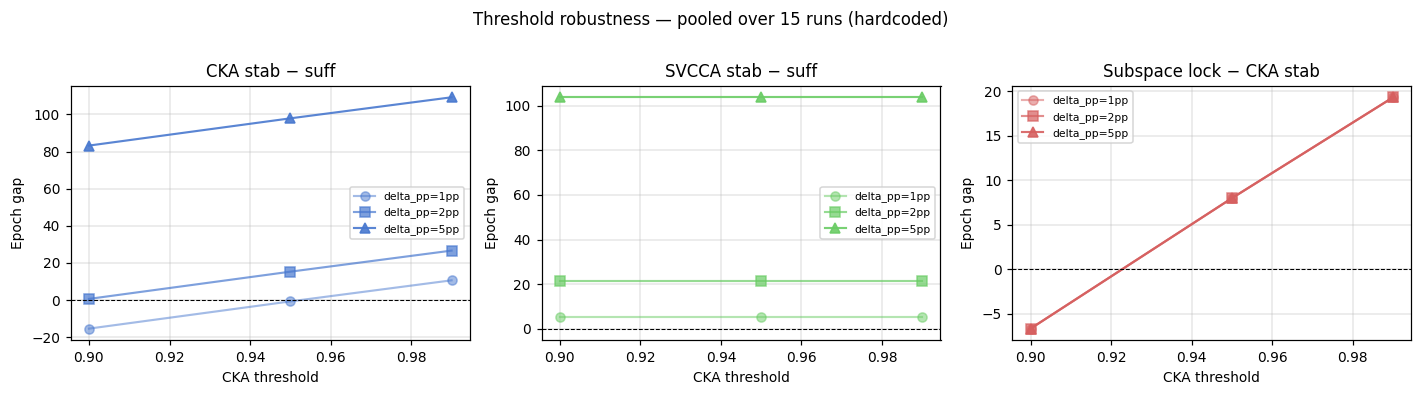

In [28]:
# ── plot: gaps vs threshold ───────────────────────────────────────────────────
if sweep_df is not None:
    thresholds = sorted(sweep_df.cka_thresh.unique())
    delta_pps  = sorted(sweep_df.delta_pp.unique())
    gap_cols   = [c for c in ['gap_cka','gap_svcca','gap_lock_vs_cka'] if c in sweep_df.columns]
    gap_labels = {'gap_cka': 'CKA stab − suff', 'gap_svcca': 'SVCCA stab − suff',
                  'gap_lock_vs_cka': 'Subspace lock − CKA stab'}
    colors_g   = {'gap_cka': '#4878CF', 'gap_svcca': '#6ACC65', 'gap_lock_vs_cka': '#D65F5F'}
    markers_d  = {1: 'o', 2: 's', 5: '^'}

    fig, axes = plt.subplots(1, len(gap_cols), figsize=(13, 3.5), sharey=False)
    if len(gap_cols) == 1: axes = [axes]
    for ax, gc in zip(axes, gap_cols):
        for dp in delta_pps:
            sub_s = sweep_df[sweep_df.delta_pp == dp].sort_values('cka_thresh')
            ax.plot(sub_s.cka_thresh, sub_s[gc],
                    marker=markers_d.get(dp, 'o'), lw=1.4,
                    color=colors_g[gc],
                    alpha=0.5 + 0.2 * delta_pps.index(dp),
                    label=f'delta_pp={dp}pp')
        ax.axhline(0, color='k', lw=0.7, ls='--')
        ax.set_xlabel('CKA threshold')
        ax.set_ylabel('Epoch gap')
        ax.set_title(gap_labels.get(gc, gc))
        ax.legend(fontsize=7)
        ax.grid(True, lw=0.3)
    fig.suptitle('Threshold robustness — pooled over 15 runs (hardcoded)', y=1.01)
    plt.tight_layout()
    plt.show()

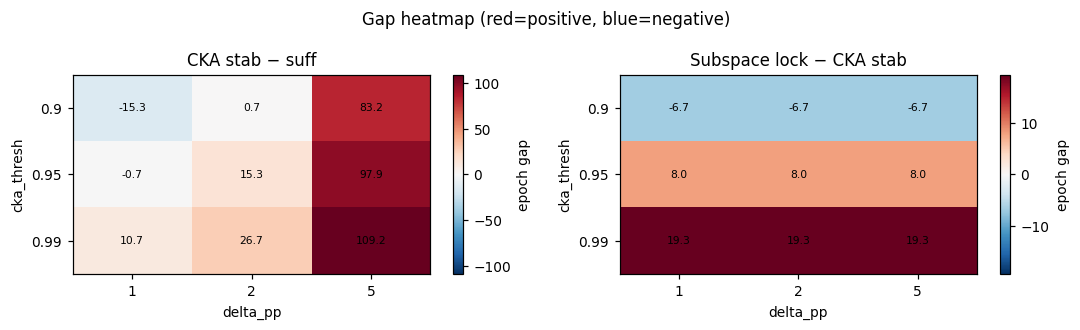

In [29]:
# ── alternative view: heatmap of gap_cka and gap_lock_vs_cka ─────────────────
if sweep_df is not None:
    hm_cols = [c for c in ['gap_cka','gap_lock_vs_cka'] if c in sweep_df.columns]
    gap_labels = {'gap_cka': 'CKA stab − suff', 'gap_svcca': 'SVCCA stab − suff',
                  'gap_lock_vs_cka': 'Subspace lock − CKA stab'}
    if hm_cols:
        fig, axes = plt.subplots(1, len(hm_cols), figsize=(5*len(hm_cols), 3))
        if len(hm_cols) == 1: axes = [axes]
        for ax, gc in zip(axes, hm_cols):
            pivot = sweep_df.pivot(index='cka_thresh', columns='delta_pp', values=gc)
            vabs  = max(abs(sweep_df[gc]))
            im    = ax.imshow(pivot.values, aspect='auto', cmap='RdBu_r',
                              vmin=-vabs, vmax=vabs)
            ax.set_xticks(range(len(pivot.columns)))
            ax.set_xticklabels(pivot.columns)
            ax.set_yticks(range(len(pivot.index)))
            ax.set_yticklabels(pivot.index)
            ax.set_xlabel('delta_pp')
            ax.set_ylabel('cka_thresh')
            ax.set_title(gap_labels.get(gc, gc))
            plt.colorbar(im, ax=ax, label='epoch gap')
            for (r, c_idx), val in np.ndenumerate(pivot.values):
                ax.text(c_idx, r, f'{val:.1f}', ha='center', va='center', fontsize=7)
        fig.suptitle('Gap heatmap (red=positive, blue=negative)')
        plt.tight_layout()
        plt.show()